# Probabilistic Mission Design - Quick Start

In [ ]:
# The imports we will need to run Probabilistic Mission Design
from promis import ProMis, StaRMap
from promis.geo import PolarLocation, CartesianMap, CartesianLocation, CartesianRasterBand, CartesianCollection
from promis.loaders import OsmLoader
from numpy import eye
import matplotlib.pyplot as plt

from promis.geo.polygon import CartesianPolygon
from promis.geo.route import CartesianRoute
import numpy as np
from pathlib import Path

In [2]:
# The features we will load from OpenStreetMap
# The dictionary key will be stored as the respective features location_type
# The dictionary value will be used to query the relevant geometry via Overpass
feature_description = {
    "park": "['leisure' = 'park']",
    "primary": "['highway' = 'primary']",
    "secondary": "['highway' = 'secondary']",
    "tertiary": "['highway' = 'tertiary']",
    "service": "['highway' = 'service']",
    "residential": "['highway' = 'residential']",
    "crossing": "['footway' = 'crossing']",
    "living_street": "[highway=living_street]",
    "unclassified": "[highway=unclassified]",
    # "bay": "['natural' = 'bay']",
    "rail": "['railway' = 'rail']",
    # oneway?
    # give way, stop?
    "signal": "['highway' = 'traffic_signals']",
}

# Covariance matrices for some of the features
# Used to draw random translations representing uncertainty for the respective features
covariance = {
    "primary": 2.5 * eye(2),
    "secondary": 2 * eye(2),
    "residential": 1.5 * eye(2),
    # "tertiary": 5 * eye(2),
    # "service": 2.5 * eye(2),
    # "operator": 20 * eye(2),
    # cov of traffic_signal?
}

# The probabilistic, logical constraints to fulfill during a mission
logic = """
    on_road(X) :-
        over(X, primary);
        over(X, secondary);
        over(X, tertiary);
        over(X, residential);
        over(X, living_street);
        over(X, unclassified);
        over(X, service).

    % Permits related to local features
    permits(X) :- 
        on_road(X),
        distance(X, signal) > 4,
        distance(X, crossing) > 2.

    % Definition of a valid mission
    landscape(X) :-  
        on_road(X).
"""

sized_logic = """
    on_road(X) :-
        distance(X, primary) < 5;
        distance(X, secondary) < 3;
        distance(X, tertiary) < 2;
        distance(X, living_street) < 2.5;
        distance(X, residential) < 2.5;
        distance(X, unclassified) < 2;
        distance(X, service) < 2.

    % Permits related to local features
    permits(X) :- 
        on_road(X),
        distance(X, signal) > 4,
        distance(X, crossing) > 2.

    % Definition of a valid mission
    landscape(X) :-  
        on_road(X).
"""

In [ ]:


# The mission area, points that will be estimated from 25 samples and points that will be interpolated
origin = PolarLocation(latitude=49.878091, longitude=8.654052)
width, height = 1000.0, 1000.0
number_of_random_maps = 25
support = CartesianRasterBand(origin, (50, 50), width, height)  # This is the set of points that will be directly computed through sampling (expensive)
target = CartesianRasterBand(origin, (250, 250), width, height)  # This is the set of points that will be interpolated from the support set (cheap)
# alternative = CartesianCollection(origin, [CartesianLocation(42, 42)])  # Alternatively, arbitrary points can be set for either set

# Setting up the Uncertainty Annotated Map from OpenStreetMap data
uam = OsmLoader(origin, (width, height), feature_description).to_cartesian_map()
uam.features.append(CartesianLocation(0.0, 0.0, location_type="operator"))  # We can manually add additional features
uam.apply_covariance(covariance)  # Assigns the covariance matrices defined earlier
uam.save(f"data/uam.pkl")  # We can save and load these objects to avoid recomputation


In [3]:
# Setting up the probabilistic spatial relations from the map data
star_map = StaRMap(target, CartesianMap.load(f"data/uam.pkl"))
star_map.initialize(support, number_of_random_maps, logic)  # This estimates all spatial relations that are relevant to the given logic
# star_map.add_support_points(support, number_of_random_maps, ["distance"], ["primary"])  # Alternatively, we can estimate for specific relations
star_map.save(f"data/star_map.pkl")

# Solve the mission area with ProMis
promis = ProMis(StaRMap.load(f"data/star_map.pkl"))
landscape = promis.solve(support, logic, n_jobs=4, batch_size=1)
landscape.save(f"data/landscape.pkl")

/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "signal"
  warn(


## Visualization

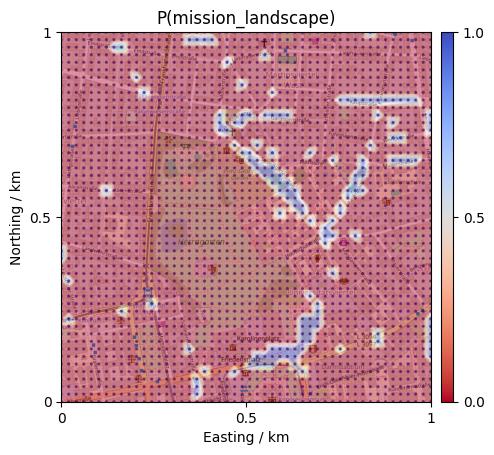

In [4]:
# ProMis' Collection classes have a scatter method that can be used to render spatial relations or probabilistic mission landscapes
landscape = CartesianCollection.load(f"data/landscape.pkl")
def plot_landscape(landscape, ax):
    image = landscape.scatter(s=0.4, plot_basemap=True, rasterized=True, cmap="coolwarm_r", alpha=0.25)


    cbar = plt.colorbar(image, ticks=[0.0, 0.5, 1.0], ax = ax, aspect=30, pad=0.02)
    cbar.ax.set_yticklabels(['0.0', '0.5', '1.0'])
    cbar.solids.set(alpha=1)

    ticks = [-500, 0, 500]
    labels = ["0", "0.5", "1"]
    support.scatter(ax = ax, alpha = 0.5, s=2)
    plt.xlabel("Easting / km")
    plt.ylabel("Northing / km")
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)
    plt.xlim([-500, 500])
    plt.ylim([-500, 500])
    plt.title("P(mission_landscape)")

plot_landscape(landscape, plt.subplot())


# Changes so far:
- Problems with resolution and interpolation
    - Streets are very slim and therefore not really detected
    - Interpolation marks buildings on curved streets as probable surface
    - much space is currently occupied by housing / non-streets, which are irrelevant for our usecase
- IDEA: 
    - move away from grid sampling strategy to get the map. 
    - It would be nice t

poly
poly
poly


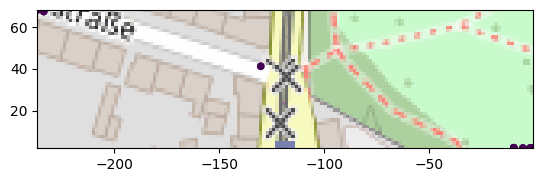

In [39]:
streets = ["residential", "living_street", ]

def map_to_locations(map: CartesianMap, filter_features: list[str], add_grid=True, grid_res: tuple[int, int] = (30, 30)) -> CartesianCollection:
    result = CartesianCollection(map.origin)
    i = 0
    for feature in map.features:
        if not feature.location_type in streets: 
            continue

        if isinstance(feature, CartesianLocation):
            result.append([feature], np.zeros((1,1)))
        elif isinstance(feature, CartesianPolygon):
            result.append(feature.locations, np.zeros((len(feature.locations), 1)))
            print("poly")
        elif isinstance(feature, CartesianRoute):
            #i += 1
            if i == 1:
                # print(len(feature.locations))
                feature.covariance = 10 * eye(2)
                samples = feature.sample(number_of_samples=5)
                print(samples)
                coll = CartesianCollection(map.origin)
                [coll.append(sample.locations, np.zeros((len(sample.locations), 1))) for sample in samples]
                coll.scatter(plot_basemap=True, s=20, alpha=0.3)
                
            ## TODO interpolate
            # grid_dist = width / grid_res[0]
            # locs = feature.locations
            # start, end = locs[0], locs[-1]
            # start.distance(end) / grid_dist
            result.append(feature.locations, np.zeros((len(feature.locations), 1)))
        else:
            print(type(feature), feature)

    if add_grid:
        grid = CartesianRasterBand(map.origin, grid_res, width, height)
        cords = grid.coordinates()
        result.append( cords, np.zeros((len(cords), 1)))
    return result

focussed_support = map_to_locations(uam, streets, add_grid=False)
#print(len(focussed_support.coordinates()))
focussed_support.scatter(s=20, plot_basemap=True)



- 1009 samples für residential / living
- viel weniger als das raster
- offset im plot? oder in den coordinaten

In [6]:
# Setting up the probabilistic spatial relations from the map data
star_map = StaRMap(target, CartesianMap.load(f"data/uam.pkl"))
star_map.initialize(focussed_support, number_of_random_maps, logic)  # This estimates all spatial relations that are relevant to the given logic
# star_map.add_support_points(support, number_of_random_maps, ["distance"], ["primary"])  # Alternatively, we can estimate for specific relations
star_map.save(f"data/star_map_focussed.pkl")

# Solve the mission area with ProMis
promis = ProMis(StaRMap.load(f"data/star_map_focussed.pkl"))
landscape = promis.solve(focussed_support, logic, n_jobs=4, batch_size=1)
landscape.save(f"data/landscape_focussed.pkl")

/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "signal"
  warn(


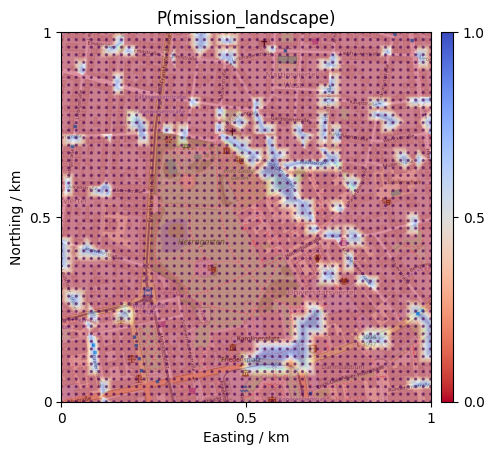

In [7]:
landscape = CartesianCollection.load("data/landscape_focussed.pkl")
plot_landscape(landscape, plt.subplot())

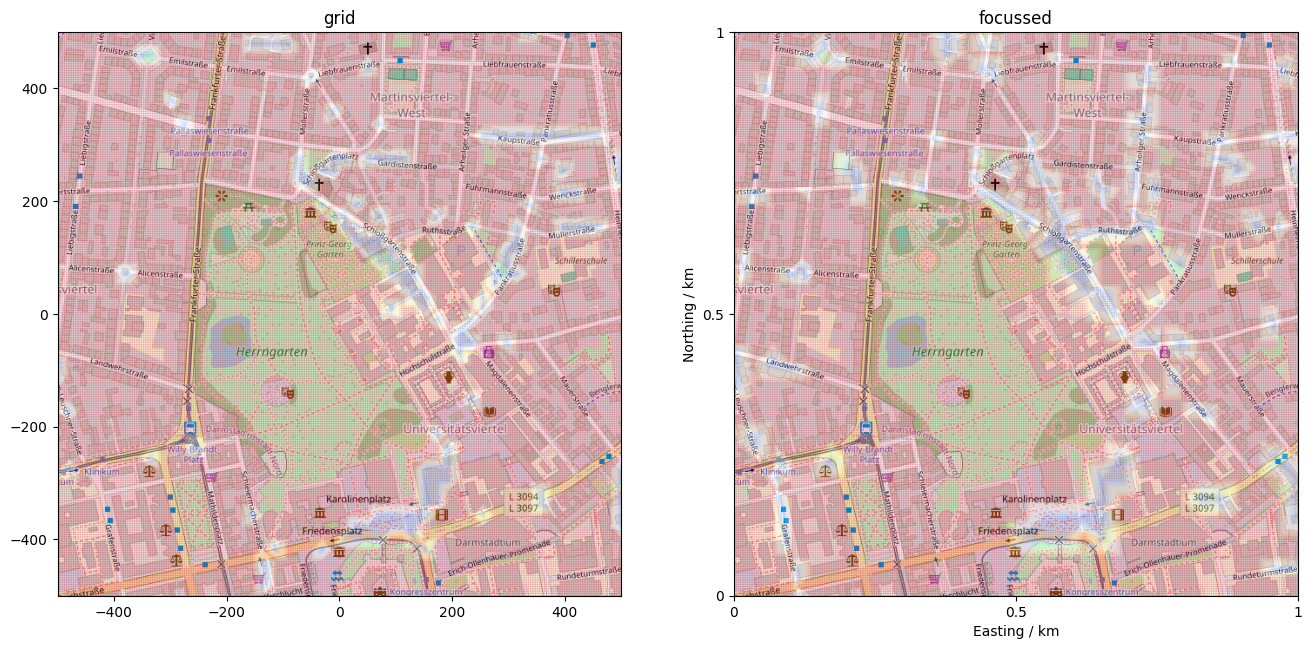

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

CartesianCollection.load("data/landscape.pkl").scatter(s=0.4, plot_basemap=True, rasterized=True, cmap="coolwarm_r", alpha=0.25, ax=axes[0])
CartesianCollection.load("data/landscape_focussed.pkl").scatter(s=0.4, plot_basemap=True, rasterized=True, cmap="coolwarm_r", alpha=0.25, ax=axes[1])

ticks = [-500, 0, 500]
labels = ["0", "0.5", "1"]
plt.xlabel("Easting / km")
plt.ylabel("Northing / km")
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)
plt.xlim([-500, 500])
plt.ylim([-500, 500])
axes[0].title.set_text("grid")
axes[1].title.set_text("focussed")

### Broad comparison

In [9]:
all_streets = ["primary", "secondary", "tertiary", "residential", "living_street", "service", "unclassified"]
street_support = map_to_locations(uam, all_streets)
# Setting up the probabilistic spatial relations from the map data
star_map = StaRMap(target, CartesianMap.load(f"data/uam.pkl"))
star_map.initialize(street_support, number_of_random_maps, logic)  # This estimates all spatial relations that are relevant to the given logic
# star_map.add_support_points(support, number_of_random_maps, ["distance"], ["primary"])  # Alternatively, we can estimate for specific relations
star_map.save(f"data/star_map_streets.pkl")

# Solve the mission area with ProMis
promis = ProMis(StaRMap.load(f"data/star_map_streets.pkl"))
landscape = promis.solve(street_support, logic, n_jobs=4, batch_size=1)
landscape.save(f"data/landscape_streets.pkl")

/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "signal"
  warn(


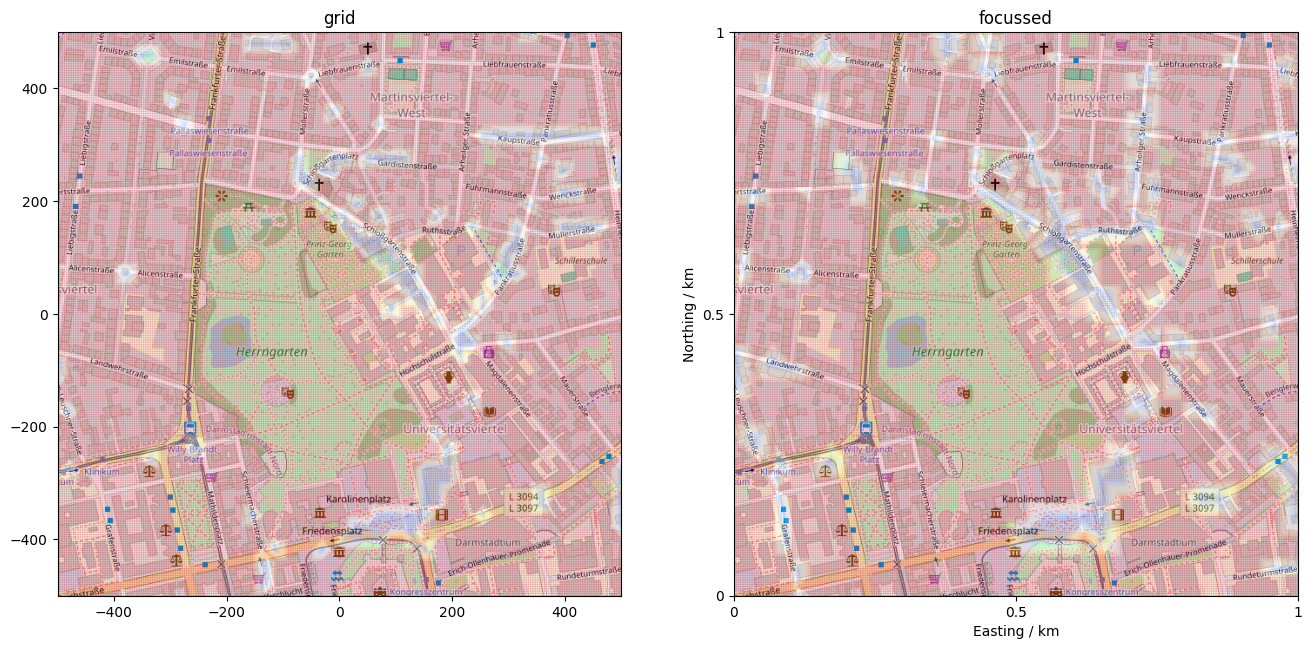

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 9))

CartesianCollection.load("data/landscape.pkl").scatter(s=0.4, plot_basemap=True, rasterized=True, cmap="coolwarm_r", alpha=0.25, ax=axes[0])
CartesianCollection.load("data/landscape_streets.pkl").scatter(s=0.4, plot_basemap=True, rasterized=True, cmap="coolwarm_r", alpha=0.25, ax=axes[1])

ticks = [-500, 0, 500]
labels = ["0", "0.5", "1"]
plt.xlabel("Easting / km")
plt.ylabel("Northing / km")
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)
plt.xlim([-500, 500])
plt.ylim([-500, 500])
axes[0].title.set_text("grid")
axes[1].title.set_text("focussed")

In [8]:
# The mission area, points that will be estimated from 25 samples and points that will be interpolated
origin = PolarLocation(latitude=49.876882, longitude=8.650317)
width, height = 80.0, 80.0
number_of_random_maps = 25
support = CartesianRasterBand(origin, (80, 80), width, height)  # This is the set of points that will be directly computed through sampling (expensive)
target = CartesianRasterBand(origin, (250, 250), width, height)  # This is the set of points that will be interpolated from the support set (cheap)
# alternative = CartesianCollection(origin, [CartesianLocation(42, 42)])  # Alternatively, arbitrary points can be set for either set

# Setting up the Uncertainty Annotated Map from OpenStreetMap data
if not Path(f"data/uam_close.pkl").exists():
    uam = OsmLoader(origin, (width, height), feature_description).to_cartesian_map()
    uam.features.append(CartesianLocation(0.0, 0.0, location_type="operator"))  # We can manually add additional features
    #uam.apply_covariance(covariance)  # Assigns the covariance matrices defined earlier
    uam.save(f"data/uam_close.pkl")  # We can save and load these objects to avoid recomputation 
uam = CartesianMap.load(f"data/uam_close.pkl")   

In [ ]:
star_map = StaRMap(target, CartesianMap.load(f"data/uam_close.pkl"))
star_map.initialize(support, number_of_random_maps, logic)  # This estimates all spatial relations that are relevant to the given logic
# star_map.add_support_points(support, number_of_random_maps, ["distance"], ["primary"])  # Alternatively, we can estimate for specific relations
star_map.save(f"data/star_map_close.pkl")

# Solve the mission area with ProMis
promis = ProMis(StaRMap.load(f"data/star_map_close.pkl"))
landscape = promis.solve(support, logic, n_jobs=4, batch_size=1)
landscape.save(f"data/landscape_close.pkl")


/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "signal"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "living_street"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "tertiary"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "unclassified"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "primary"
  warn(


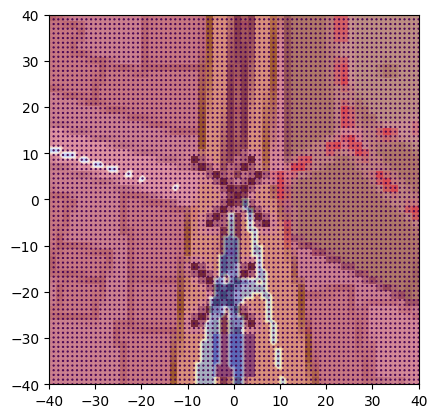

In [30]:

ax = plt.subplot()
landscape = CartesianCollection.load("data/landscape_close.pkl")
landscape.scatter(s=0.4, plot_basemap=True, rasterized=True, cmap="coolwarm_r", alpha=0.25, ax=ax)
support.scatter(s=0.4, ax=ax)
plt.show()

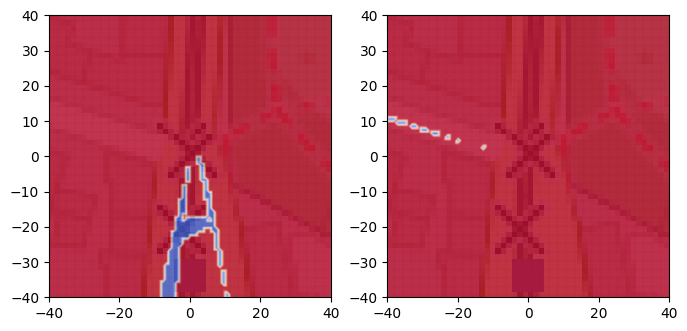

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8,4))
secondary = star_map.get("over", "secondary")
secondary.parameters.scatter(s=0.4, cmap="coolwarm_r", alpha=0.4, ax=axes[0], plot_basemap=True)
star_map.get("over", "residential").parameters.scatter(s=0.4, cmap="coolwarm_r", alpha=0.4, ax=axes[1], plot_basemap=True, rasterized=True)
secondary.parameters.to_csv("data/over_secondary.csv")


In [9]:
star_map = StaRMap(target, CartesianMap.load(f"data/uam_close.pkl"))
star_map.initialize(support, number_of_random_maps, sized_logic)  # This estimates all spatial relations that are relevant to the given logic
# star_map.add_support_points(support, number_of_random_maps, ["distance"], ["primary"])  # Alternatively, we can estimate for specific relations
star_map.save(f"data/sized_star_map_close.pkl")

# Solve the mission area with ProMis
promis = ProMis(StaRMap.load(f"data/sized_star_map_close.pkl"))
landscape = promis.solve(support, sized_logic, n_jobs=4, batch_size=1)
landscape.save(f"data/sized_landscape_close.pkl")

/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "unclassified"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "signal"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "primary"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "tertiary"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "living_street"
  warn(

AttributeError: type object 'OsmLoader' has no attribute 'compute_bounding_box'

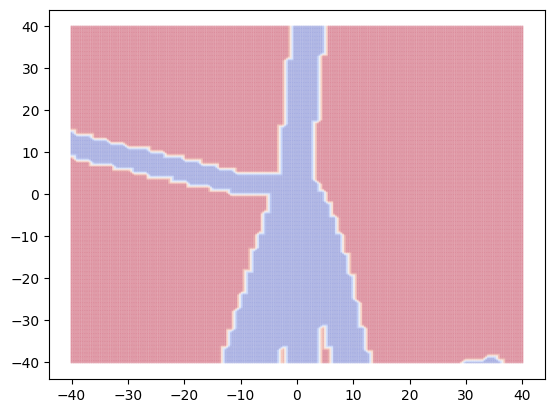

In [12]:

ax = plt.subplot()
landscape = CartesianCollection.load("data/sized_landscape_close.pkl")
landscape.scatter(s=0.4, plot_basemap=False, rasterized=True, cmap="coolwarm_r", alpha=0.25, ax=ax)
support.scatter(s=0.4, ax=ax)
plt.show()

In [ ]:
methods = ["linear", "nearest", "gaussian_process"]
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for i, method in enumerate(methods):
    filename = f"data/close_{method}.pkl"
    axis = axes[i]
    if Path(filename).exists():
        landscape = StaRMap.load(filename) 
    else:
        star_map = StaRMap(target, CartesianCollection.load("data/uam_close.pkl"), method=method)
        star_map.initialize(support, 25, logic)
        promis = ProMis(star_map)
        landscape = promis.solve(support, logic, n_jobs=4, batch_size=1)
        landscape.save(filename)
    axis.title.set_text(method)
    landscape.scatter(s=0.4, cmap="coolwarm_r", alpha=0.4, ax=axis, plot_basemap=True, rasterized=True)


/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "unclassified"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "living_street"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "tertiary"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "over" for location type "primary"
  warn(
/home/julius/Documents/ba_inf_6/bachelorarbeit/ProMis/.venv/lib/python3.10/site-packages/promis/star_map.py:478: UserWarning: no features for relation "distance" for location type "signal"
  warn(
/home/julius/Do